In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#models
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error


In [17]:
#import data from EDA nootbook

import import_ipynb
from nootbook import EDA
df = EDA.df
num_col = EDA.num_col
non_num_col = EDA.non_num_col

### Train test split


In [26]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['Average_Score','Total_Score'])
y = df['Average_Score']
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

### Column transformation

In [18]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

ohe = OneHotEncoder(drop='first')
scaler = StandardScaler()

preprocessor = ColumnTransformer([
    ('Standard-scaler', scaler, num_col),
    ('One-hot-encoder', ohe, non_num_col)
])



In [19]:
x_train_scaled = preprocessor.fit_transform(x_train)
x_test_scaled = preprocessor.transform(x_test)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,-0.299452,0.030791,0.434053,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
1,-0.033050,0.930290,0.964701,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.832756,1.345443,1.163694,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,-0.366053,-0.176786,-0.162925,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,0.433153,-0.384363,-0.759904,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
795,1.365559,2.106557,2.092328,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0
796,0.166751,-0.453555,-0.494580,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
797,-0.898857,-0.522747,-1.025228,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
798,-1.098658,-1.491438,-1.025228,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


### Train models

In [32]:
models={
    "LinearRegression":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(),
    "SVR":SVR(),
    "KNeighborsRegressor":KNeighborsRegressor(),
    "DecisionTreeRegressor":DecisionTreeRegressor(),
    "RandomForestRegressor":RandomForestRegressor(),
    "AdaBoostRegressor":AdaBoostRegressor(),
    "GradientBoostingRegressor":GradientBoostingRegressor(),
    "XGBoostRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor()

}

In [34]:
score = {}

for name,model in models.items():
    model.fit(x_train_scaled,y_train)
    y_pred_train = model.predict(x_train_scaled)
    y_pred = model.predict(x_test_scaled)


    r2_score_train = r2_score(y_train,y_pred_train)
    mean_squared_error_train = mean_squared_error(y_train,y_pred_train)
    mean_absolute_error_train = mean_absolute_error(y_train,y_pred_train)

    r2_score_test = r2_score(y_test,y_pred)
    mean_squared_error_test = mean_squared_error(y_test,y_pred)
    mean_absolute_error_test = mean_absolute_error(y_test,y_pred)

    score[name] = r2_score_test
    print("Model: ",name)
    print(f"Traing score:\n r2_score : {r2_score_train} \n mean_squared_error_train : {mean_squared_error_train} \n  mean_absolute_error_train : {mean_absolute_error_train}" )
    print("_"*32)
    print(f"Test_score: \n r2_score : {r2_score_test} \n mean_squared_error_test : {mean_squared_error_test} \n  mean_absolute_error_test: {mean_absolute_error_test}")
    print("="*32)






Model:  LinearRegression
Traing score:
 r2_score : 1.0 
 mean_squared_error_train : 3.1934667165157e-28 
  mean_absolute_error_train : 1.55830903736387e-14
________________________________
Test_score: 
 r2_score : 1.0 
 mean_squared_error_test : 3.5789041548066864e-28 
  mean_absolute_error_test: 1.6964207816272393e-14
Model:  Ridge
Traing score:
 r2_score : 0.9999996865871573 
 mean_squared_error_train : 6.25100154056763e-05 
  mean_absolute_error_train : 0.006402042244951675
________________________________
Test_score: 
 r2_score : 0.9999996481504501 
 mean_squared_error_test : 7.542478000312128e-05 
  mean_absolute_error_test: 0.0065924578654553475
Model:  Lasso
Traing score:
 r2_score : 0.9944174815680811 
 mean_squared_error_train : 1.1134301649563683 
  mean_absolute_error_train : 0.8431428722450014
________________________________
Test_score: 
 r2_score : 0.9943142483570857 
 mean_squared_error_test : 1.2188350586108991 
  mean_absolute_error_test: 0.8678574472533017
Model:  SVR

In [35]:
score

{'LinearRegression': 1.0,
 'Ridge': 0.9999996481504501,
 'Lasso': 0.9943142483570857,
 'SVR': 0.8571003606929378,
 'KNeighborsRegressor': 0.9698863696147476,
 'DecisionTreeRegressor': 0.9889674960196685,
 'RandomForestRegressor': 0.9941108517077524,
 'AdaBoostRegressor': 0.9780992609373215,
 'GradientBoostingRegressor': 0.9957366667546008,
 'XGBoostRegressor': 0.9952246801563606,
 'CatBoostRegressor': 0.9946764286410849}

### observation ---> linear reg perform well

In [36]:
regressor = LinearRegression()
regressor.fit(x_train_scaled,y_train)
y_pred = regressor.predict(x_test_scaled)

<Axes: xlabel='Average_Score'>

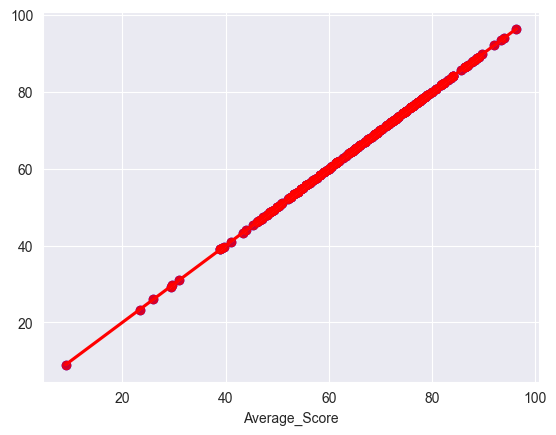

In [40]:
plt.scatter(y_test,y_pred,color='blue')
sns.regplot(x=y_test,y=y_pred,color='red')